Grand scheme (thesis story)
--------------------------
 We want to reconcile two measurements of feeder/transformer current:
   (1) Janitza at substation transformer level  -> "ground truth-ish" but can be CT-scaled wrong / wiring mixups
   (2) Sum of smart meters on that transformer -> trusted for billing, but incomplete (missing meters, unmetered load, NTL)

 Model (per substation, transformer):
   I_jan(t) = k * I_sm_true(t) + (unmetered + NTL)(t) + noise

 We do NOT observe I_sm_true directly; we observe I_sm_sum and a coverage estimate per_completed.
 So we approximate:
   I_sm_adj(t) = I_sm_sum(t) / per_completed   (coverage-adjusted smart meter current)

 Goal of this notebook:
 1) Clean + align both time series on identical 15-min bins per (substation, transformer)
 2) Estimate k per (substation, transformer) using *low-quantile regression* to fit the lower envelope
    (lower envelope ~ "times when unmetered+NTL is minimal")
 3) Correct Janitza scale by dividing by k
 4) Define Delta(t) = I_jan_corr(t) - I_sm_adj(t) as proxy for unmetered+NTL+mismatch
 5) QC/flag groups where mapping/transformer swap/physics assumptions fail

1399 sp1 : 2600/5 to 1200/5
1400 sp1 : 1600/5 to 1200/5
1364 sp1 : 2250/5 to 1200/5
1364 sp2 : 1200/5 to 1200/5
411 sp1 : 1200/5 to 1200/5
145 sp1 : 1200/5 to 1200/5
1029 sp1 : 1200/5 to 1200/5
1379 sp1 : 1200/5 to 1200/5
670 sp1 : 1200/5 to 1200/5
1482 sp1 : 1200/5 to 1200/5
1416 sp1 1200/5 to 1200/5
1248 sp2 : 1200/5 to 1200/5
1454 sp1 : 1200/5 to 1200/5
1049 sp2 : 1200/5 to 1200/5
1383 sp1 : 1200/5 to 1200/5
537 sp1 : 1200/5 to 1200/5
1354 sp2 : 1200/5 to 1600/5 or 2000/5
1496 sp1 : 1200/5 to 1200/5
1248 sp1 : 1200/5 to 1200/5
1364 sp1 : 2250/5 to 1200/5



In [9]:

# Functions + imports
#################################################################################################################
# Core libraries for cleaning, grouping, merging, and quick plots.
# (Note: sklearn LinearRegression imported but not used here; ok to keep for later baseline comparisons.)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math
import phasebalance.phase_unbalance_utils as m
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception as e:
    HAVE_SM = False
    print("statsmodels not available -> will use ratio-quantile fallback.")
    print("Error:", e)   

def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-(substation, transformer) diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, transformer, ts,
      I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    required = {"substation_id", "transformer", "I_total_sm", "I_total_jn"}
    missing = required - set(merged.columns)
    if missing:
        raise KeyError(f"compute_ct_diagnostics: merged is missing required columns: {sorted(missing)}")

    # Normalize transformer just in case
    m = merged.copy()
    m["transformer"] = m["transformer"].astype(str).str.strip().str.lower()

    for (sid, tr), g in m.groupby(["substation_id", "transformer"], dropna=False):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].to_numpy()
        y = g["I_total_jn"].to_numpy()

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = float(sm_gt_jn.mean())

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = float(np.sum((y - y_pred) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = (g["I_total_jn"] / g["I_total_sm"]).replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        if float(np.sum(x**2)) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        alpha_max_phys = ratio_p05  # use ratio_min if you want strict
        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g.columns:
            per_completed = float(pd.to_numeric(g["per_completed"], errors="coerce").max())
            if per_completed > 1.5:  # handle 0–100 scale
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(pd.to_numeric(g["n_mps"], errors="coerce").max()) if "n_mps" in g.columns else np.nan

        if per_completed and (not np.isnan(per_completed)) and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,   # 👈 NEW OUTPUT KEY
            # Unconstrained regression fit (with intercept)
            "alpha_ls": float(alpha_ls),
            "beta": float(beta),
            "r2": float(r2) if not np.isnan(r2) else np.nan,
            "corr": float(corr) if corr is not None else np.nan,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": int(len(g)),
        })

    return pd.DataFrame(rows)

def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_substation_scatter(merged, sid, transformer=None, alpha=None):
    g = merged[merged["substation_id"] == sid].copy()
    if transformer is not None:
        g = g[g["transformer"].astype(str).str.strip().str.lower() == str(transformer).strip().lower()]

    if g.empty:
        raise ValueError(f"No rows found for substation_id={sid}, transformer={transformer}")

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    tx = f" | {transformer}" if transformer else ""
    plt.title(f"Substation {sid}{tx} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_robust_comparison(stats_df, top_n=300):
    """
    Plots MAE (Amps), RMSE (Amps), and WAPE (%) stacked vertically.
    stats_df is indexed by (substation_id, transformer).
    """
    data = stats_df.head(top_n).copy()

    x = np.arange(len(data))
    width = 0.35
    subs = [f"{sid}_{tr}" for (sid, tr) in data.index]  # 👈 nicer labels

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

    ax1.bar(x - width/2, data["MAE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax1.bar(x + width/2, data["MAE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax1.set_ylabel('MAE [Amps]')
    ax1.set_title(f'Mean Absolute Error (MAE) - Top {top_n} (Substation, Trafo)')
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)

    ax2.bar(x - width/2, data["RMSE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax2.bar(x + width/2, data["RMSE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax2.set_ylabel('RMSE [Amps]')
    ax2.set_title('Root Mean Square Error (RMSE)')
    ax2.grid(True, axis='y', alpha=0.3)

    ax3.bar(x - width/2, data["WAPE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax3.bar(x + width/2, data["WAPE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax3.set_ylabel('WAPE [%]')
    ax3.set_title('Weighted Percentage Error (WAPE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(subs, rotation=90)
    ax3.grid(True, axis='y', alpha=0.3)

    for i, n in enumerate(data["n_mps"]):
        y_pos = max(data["WAPE_Before"].iloc[i], data["WAPE_After"].iloc[i])
        offset = 0.05 * data["WAPE_Before"].max()
        ax3.text(i, y_pos + offset, f"n={int(n)}", ha='center', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()

def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_transformers=None,   # NEW: list of (substation_id, transformer) pairs
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per (substation, transformer).

    For each (substation, transformer):
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm
    """

    # Defensive normalize transformer strings
    merged = merged.copy()
    summary = summary.copy()
    if "transformer" not in merged.columns or "transformer" not in summary.columns:
        raise KeyError("Both merged and summary must contain a 'transformer' column.")

    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # --- choose which (substation, transformer) pairs to plot ---
    if substation_transformers is not None:
        pairs = [(sid, str(tr).strip().lower()) for sid, tr in list(substation_transformers)[:max_plots]]
        cand = summary.merge(
            pd.DataFrame(pairs, columns=["substation_id", "transformer"]),
            on=["substation_id", "transformer"],
            how="inner",
        )
    else:
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by (substation_id, transformer)
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values(["substation_id", "transformer"])

        cand = cand.head(max_plots)

        pairs = list(zip(cand["substation_id"], cand["transformer"]))

    if not pairs:
        print("No (substation, transformer) pairs to plot (check filters or substation_transformers).")
        return

    # Lookup diagnostics by (substation_id, transformer)
    summary_idx = summary.set_index(["substation_id", "transformer"])

    # --- create grid of subplots ---
    n_plots = len(pairs)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, (sid, tr) in zip(axes, pairs):
        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # alpha_ct for this (sid, tr)
        alpha = None
        if "alpha_ct" in summary.columns and (sid, tr) in summary_idx.index:
            alpha_val = summary_idx.loc[(sid, tr), "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Title
        title = f"Sub {sid} {tr}"
        if "corr" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f"\nρ={float(summary_idx.loc[(sid, tr), 'corr']):.2f}"
            except Exception:
                pass
        if "per_completed" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f", per={float(summary_idx.loc[(sid, tr), 'per_completed']):.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Transformer total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

def calculate_robust_metrics(df_in, sm_col="I_total_sm", jn_col="I_total_jn", min_current_mape=5.0):
    """
    Calculates row-wise error metrics and aggregates them per (substation_id, transformer).
    Returns a DataFrame indexed by (substation_id, transformer).
    """
    df = df_in.copy()

    # Defensive normalize transformer
    if "transformer" in df.columns:
        df["transformer"] = df["transformer"].astype(str).str.strip().str.lower()
    else:
        raise KeyError("calculate_robust_metrics: df_in must contain a 'transformer' column now.")

    # 1. Basic Difference
    df["diff"] = df[sm_col] - df[jn_col]
    df["abs_diff"] = df["diff"].abs()
    df["sq_diff"] = df["diff"] ** 2

    # 2. Standard MAPE (filtered)
    high_load_mask = df[sm_col] > min_current_mape
    df["mape_filtered"] = np.nan
    df.loc[high_load_mask, "mape_filtered"] = (
        100 * df.loc[high_load_mask, "abs_diff"] / df.loc[high_load_mask, sm_col]
    )

    # 3. SMAPE
    denom = (df[sm_col].abs() + df[jn_col].abs()) / 2
    df["smape"] = 100 * df["abs_diff"] / denom.replace(0, np.nan)

    # --- AGGREGATION (NOW PER substation + transformer) ---
    stats = df.groupby(["substation_id", "transformer"]).agg(
        # Context
        n_points      = (sm_col, "count"),
        n_mps         = ("n_mps", "max"),
        per_completed = ("per_completed", "max"),

        # Absolute Errors (Amps)
        MAE           = ("abs_diff", "mean"),
        RMSE          = ("sq_diff", lambda x: np.sqrt(x.mean())),

        # Percentage Errors
        MAPE_filtered_mean = ("mape_filtered", "mean"),
        SMAPE_mean         = ("smape", "mean"),

        # Sums for WAPE
        sum_abs_diff = ("abs_diff", "sum"),
        sum_sm_total = (sm_col, "sum"),
    )

    stats["WAPE"] = 100 * stats["sum_abs_diff"] / stats["sum_sm_total"].replace(0, np.nan)
    return stats

def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,
):
    """
    Grid of scatter plots for each (substation_id, transformer):
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that pair becomes 1.0.
    The slope α is preserved.
    """

    # Basic required cols
    for c in ["substation_id", "transformer", "I_total_sm", "I_total_jn"]:
        if c not in merged.columns:
            raise KeyError(f"merged missing column: {c}")
    for c in ["substation_id", "transformer", "per_completed", "n_points", "alpha_ct", "alpha_over_expected", "r2"]:
        if c not in summary.columns:
            raise KeyError(f"summary missing column: {c}")

    # Normalize transformer strings (defensive)
    merged = merged.copy()
    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary = summary.copy()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # Filter to reasonably complete (substation, transformer) groups
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No (substation, transformer) groups meet the per_completed and n_points filters.")
        return

    # Sort so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False).head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, compute global max across selected pairs
    global_max = 0.0
    if not normalize:
        for _, r in cand.iterrows():
            sid = r["substation_id"]
            tr = r["transformer"]
            g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
            g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered groups have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        tr = row["transformer"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
        g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        ax.scatter(x, y, s=5, alpha=0.3)
        ax.plot(xs, xs, "k--", linewidth=1)                 # JD = SMD
        ax.plot(xs, alpha * xs, linewidth=1)                # JD = alpha * SMD

        ax.set_title(
            f"Sub {sid} {tr}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"Substation meter vs Smart meter – (substation, trafo) with per_completed ≥ {min_per_completed}",
        y=0.99,
    )
    plt.tight_layout()
    plt.show()

def fit_k_no_intercept(df_reg, tau=0.20, min_points=200):
    """
    Fits quantile regression WITHOUT intercept:
      I_total_jn ≈ k0 * I_total_sm_adj
    Often preferred for CT scaling correction because it enforces 0->0 behavior.
    """
    rows = []
    for (sid,tr), g in df_reg.groupby(["substation_id","transformer"]):
        if len(g) < min_points:
            continue
        x = g["I_total_sm_adj"].to_numpy(float)
        y = g["I_total_jn"].to_numpy(float)
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        if HAVE_SM:
            # X is just x, no constant column
            try:
                res = sm.QuantReg(y, x).fit(q=tau, max_iter=2000)
                k0 = float(res.params[0])
            except Exception:
                k0 = float(np.nanquantile(y/x, tau))
        else:
            k0 = float(np.nanquantile(y/x, tau))

        rows.append({"substation_id": sid, "transformer": tr, "tau": tau, "k_hat0": k0, "n_points": len(x)})
    return pd.DataFrame(rows)

def load_and_clean_devices(path):
    """Loads device metadata and ensures unique device_id per row."""
    df = pd.read_csv(path)
    df["device_id"] = pd.to_numeric(df["device_id"], errors="coerce").astype("Int64")
    
    # Keep first occurrence of device_id if duplicates exist
    return (
        df.dropna(subset=["device_id"])
        .drop_duplicates(subset=["device_id"], keep="first")
    )
#################################################################################################################

In [12]:
## Load + preprocess + align time bins (this is the "make the join trustworthy" section)
#################################################################################################################
sm_current_path = "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG'].parquet"
jn_current_path = "../data/janitza_timeseries_2026-01-23_1936_All_mes.parquet"
devices_list = "../metadata/devices.csv"

# Read raw parquet outputs 
df_devices = pd.read_csv(devices_list) # Here I load up the device metadata that tells me what device is in what measurement group
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)


#### Ammending feeder and dnr_str to Janitza data ####
df_jn_current["device_id"] = pd.to_numeric(df_jn_current["device_id"], errors="coerce").astype("Int64")
df_devices["device_id"] = pd.to_numeric(df_devices["device_id"], errors="coerce").astype("Int64")

# 2) (Optional but recommended) ensure single row per device_id in df_devices
#    If df_devices has duplicates, we keep the first occurrence.
devices_lookup = (
    df_devices[["device_id", "feeder", "dnr_str"]]
    .dropna(subset=["device_id"])
    .drop_duplicates(subset=["device_id"], keep="first")
)
# 3) Left-join so df_jn_current keeps all its rows
df_jn_current = df_jn_current.merge(devices_lookup, on="device_id", how="left",)
df_jn_current = df_jn_current.rename(columns={"feeder": "transformer"}) # rename feeder to transformer for consistency
#### End amending Janitza data ####


# Normalize transformer key to avoid merge failures ("SP1" vs "sp1", whitespace, etc.) 
for d in (df_sm_current, df_jn_current):
    if "transformer" in d.columns:
        d["transformer"] = d["transformer"].astype(str).str.strip().str.lower()

# Add numeric substation_id from Janitza naming convention
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(m.parse_dnr)

# Optional: exclude known broken substations (manual blacklist)
#exclude_dnr = ["D1133"]  # e.g. ["D0303", "D1454","D1554","D1049"]
#df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()
# =========================================================
# NEW FILTER: Exclude Low-Meter-Count Groups (n_mps <= 2)
# =========================================================
# We calculate max meters seen per group to determine if it's "low meter count"
if "n_mps" in df_sm_current.columns:
    # 1. Identify valid groups
    valid_groups = (
        df_sm_current.groupby(["substation_id", "transformer"])["n_mps"]
        .max()
        .reset_index()
    )
    valid_groups = valid_groups[valid_groups["n_mps"] > 0] # Strict > 2 (so 3 or more)
    
    print(f"Filtering: Keeping {len(valid_groups)} groups with > 2 meters.")
    
    # 2. Filter Smart Meter DataFrame
    df_sm_current = df_sm_current.merge(
        valid_groups[["substation_id", "transformer"]], 
        on=["substation_id", "transformer"], 
        how="inner"
    )
    
    # 3. Filter Janitza DataFrame (to avoid processing irrelevant stations)
    df_jn_current = df_jn_current.merge(
        valid_groups[["substation_id", "transformer"]], 
        on=["substation_id", "transformer"], 
        how="inner"
    )
else:
    print("WARNING: 'n_mps' column missing in Smart Meter data. skipping low-meter filter.")
# =========================================================
# Sort for readability + predictable operations
df_sm_current = df_sm_current.sort_values(["substation_id", "ts"])
df_jn_current = df_jn_current.sort_values(["substation_id", "ts"])

# Timestamp normalization:
# - Smartmeter data typically already timezone-naive
# - Janitza often comes with timezone awareness (UTC); convert and strip tz to compare properly in pandas merges
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# Keep only substations that exist in Janitza (we only regress where both sources exist)
jn_substations = df_jn_current["substation_id"].unique()
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()

# Ensure both are datetime (defensive)
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"])


# Key alignment fix:
# Janitza timestamps may be slightly offset from exact 15-min boundaries.
# We snap to 15-min bins with tolerance, avoiding "ceil gaps" that create missing bins.
tol = pd.Timedelta(seconds=10)  # small tolerance window

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor


# If timestamp is only a few seconds after boundary -> treat as boundary.
# Else snap up (ceil) so bins align with the smartmeter aggregator convention.
df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# Trim both datasets to same end time to avoid trailing bins in one source only
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# Janitza collisions:
# If Janitza has multiple rows per (substation, transformer, ts) (device-level or exporter duplication),
# we aggregate to one record per bin. Mean is a pragmatic choice here; document in thesis.


# Row-wise total current
df_jn_current["I_total"] = (df_jn_current["Ia_avg"] + df_jn_current["Ib_avg"] + df_jn_current["Ic_avg"])

df_test = df_jn_current.copy()

num_cols = ["Ia_avg", "Ib_avg", "Ic_avg", "I_total"]
df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts", "transformer"], as_index=False)[num_cols]
    .mean()
)

# Define the "comparison universe":
# We only compare bins where Janitza exists (JD-present bins). This avoids blaming smartmeters for missing Janitza buckets.
grid = m.make_expected_grid(df_jn_current)
jn_bins = df_jn_current[["substation_id", "ts", "transformer"]].drop_duplicates()

grid = grid.merge(
    jn_bins.assign(jn_present=1),
    on=["substation_id", "ts", "transformer"],
    how="left"
)
grid["jn_present"] = grid["jn_present"].fillna(0).astype(int)

good_bins = grid[grid["jn_present"] == 1][["substation_id", "ts", "transformer"]]

# Filter both sources to exactly these bins (merge safety + fair comparison)
df_jn_good = df_jn_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")
df_sm_good = df_sm_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")

# Sanity: sizes and duplicate key checks (crucial when joins feel scary)
print("Original:", df_jn_current.shape, df_sm_current.shape)
print("Common-bin:", df_jn_good.shape, df_sm_good.shape)

print("Duplicate keys in JN good:", df_jn_good.duplicated(["substation_id", "ts", "transformer"]).sum())
print("Duplicate keys in SM good:", df_sm_good.duplicated(["substation_id", "ts", "transformer"]).sum())

#################################################################################################################


Filtering: Keeping 81 groups with > 2 meters.
Original: (699283, 7) (705715, 9)
Common-bin: (699283, 7) (698435, 9)
Duplicate keys in JN good: 0
Duplicate keys in SM good: 0


In [25]:
# df_jn_filtered, _ = m.filter_devices_by_name_pattern(df_jn_enriched, df_devices)
df_devices = load_and_clean_devices(devices_list)
df_jn_new,toremove = m.filter_devices_by_name_pattern(df_test, df_devices)

In [26]:
toremove

4        5
5        6
6        7
7        8
8        9
      ... 
355    461
360    466
362    468
363    469
364    470
Name: device_id, Length: 174, dtype: Int64

In [19]:
df_test.shape[1]

67

In [3]:
# Merge smartmeter + Janitza into one frame (this is the regression input "panel dataset")
#################################################################################################################
# After this merge:
#   Each row = one 15-min bin for one (substation_id, transformer)
#   Contains both currents, coverage metadata, etc.

df_sm_good = df_sm_good.rename(columns={"I_a": "Ia_avg", "I_b": "Ib_avg", "I_c": "Ic_avg"})

df_merged = df_sm_good.merge(
    df_jn_good,
    on=["substation_id", "ts","transformer"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
# Quick differences (not the final model, but good for debugging & intuition)
for col in ["Ia_avg", "Ib_avg", "Ic_avg", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["Ia_avg_diff", "Ib_avg_diff", "Ic_avg_diff", "I_total_diff"]].describe()

print("Merged shape:",df_merged.shape)
#################################################################################################################

Merged shape: (698435, 17)


In [4]:
# Coverage adjustment + regression eligibility filters
#################################################################################################################
# Why this cell exists:
# Smartmeter sum is not the true transformer load if meters are missing.
# per_completed approximates fraction of load that is metered.
# We adjust:
#   I_total_sm_adj = I_total_sm / per_completed
# Then we regress Janitza on SM_adj.

# Regression filters:
# - remove low-current points (ratios/quantiles unstable near zero)
# - require good coverage (so slope is less confounded by missing meters)
# - require lots of points per group (stable quantile estimation)
min_current = 5.0
min_per_completed = 0.88
min_points = 6000


df = df_merged.copy()

# Clean per_completed: some sources store as 0-100 (%) rather than 0-1 fraction.
df["per_completed"] = pd.to_numeric(df["per_completed"], errors="coerce")
mask_pct = df["per_completed"] > 1.5
df.loc[mask_pct, "per_completed"] = df.loc[mask_pct, "per_completed"] / 100.0

# Outside (0,1] doesn't make physical sense -> treat as missing
df.loc[(df["per_completed"] <= 0) | (df["per_completed"] > 1.0), "per_completed"] = np.nan

# Coverage-adjusted smartmeter current (proxy for "true metered load")
df["I_total_sm_adj"] = df["I_total_sm"] / df["per_completed"]
df.loc[~np.isfinite(df["I_total_sm_adj"]), "I_total_sm_adj"] = np.nan


df_reg = df[
    (df["I_total_sm"].abs() > min_current) &
    (df["I_total_jn"].abs() > min_current) &
    (df["per_completed"] >= min_per_completed) &
    (df["I_total_sm_adj"] > 0) &
    np.isfinite(df["I_total_sm_adj"]) &
    np.isfinite(df["I_total_jn"])
].copy()

print("df_reg shape:", df_reg.shape)
print("Unique (sub,trafo):", df_reg.groupby(["substation_id","transformer"]).ngroups)

# Sanity: group sizes and how many fail min_points (helps tune thresholds)
gsize = df_reg.groupby(["substation_id", "transformer"]).size().sort_values(ascending=False)
display(gsize.head(10))
print("Groups with < min_points:", (gsize < min_points).sum(), "/", len(gsize))
#################################################################################################################

df_reg shape: (316440, 18)
Unique (sub,trafo): 38


substation_id  transformer
537            sp1            8832
411            sp1            8832
579            sp1            8832
1030           sp1            8832
1029           sp1            8832
670            sp1            8832
1383           sp1            8832
1364           sp2            8832
1399           sp1            8832
1049           sp2            8832
dtype: int64

Groups with < min_points: 3 / 38


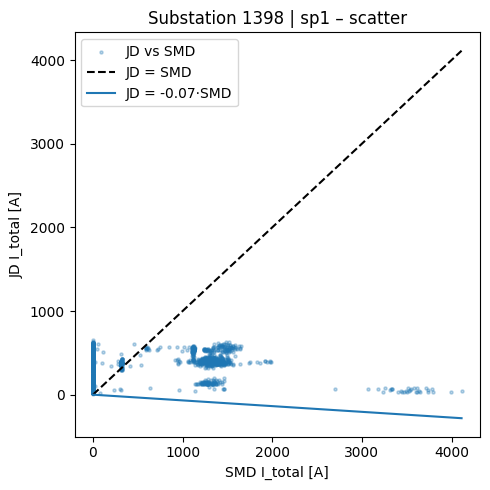

In [5]:
# This code block is for computing diagnostics and plotting and showing that the CT scaling is issue that is causing the diffences between the two datasets.
#################################################################################################################
df_computed = compute_ct_diagnostics(df_merged)
substation_id = 1398
transformer = "sp1"  # or "sp2"

alpha = df_computed.loc[
    (df_computed["substation_id"] == substation_id) &
    (df_computed["transformer"] == transformer),
    "alpha_ls"
].values[0]

plot_substation_scatter(
    merged=df_merged,
    sid=substation_id,
    transformer=transformer,
    alpha=alpha,
)
#################################################################################################################


If the issue is CT scaling then we expect the dots to be spread around the corrected line

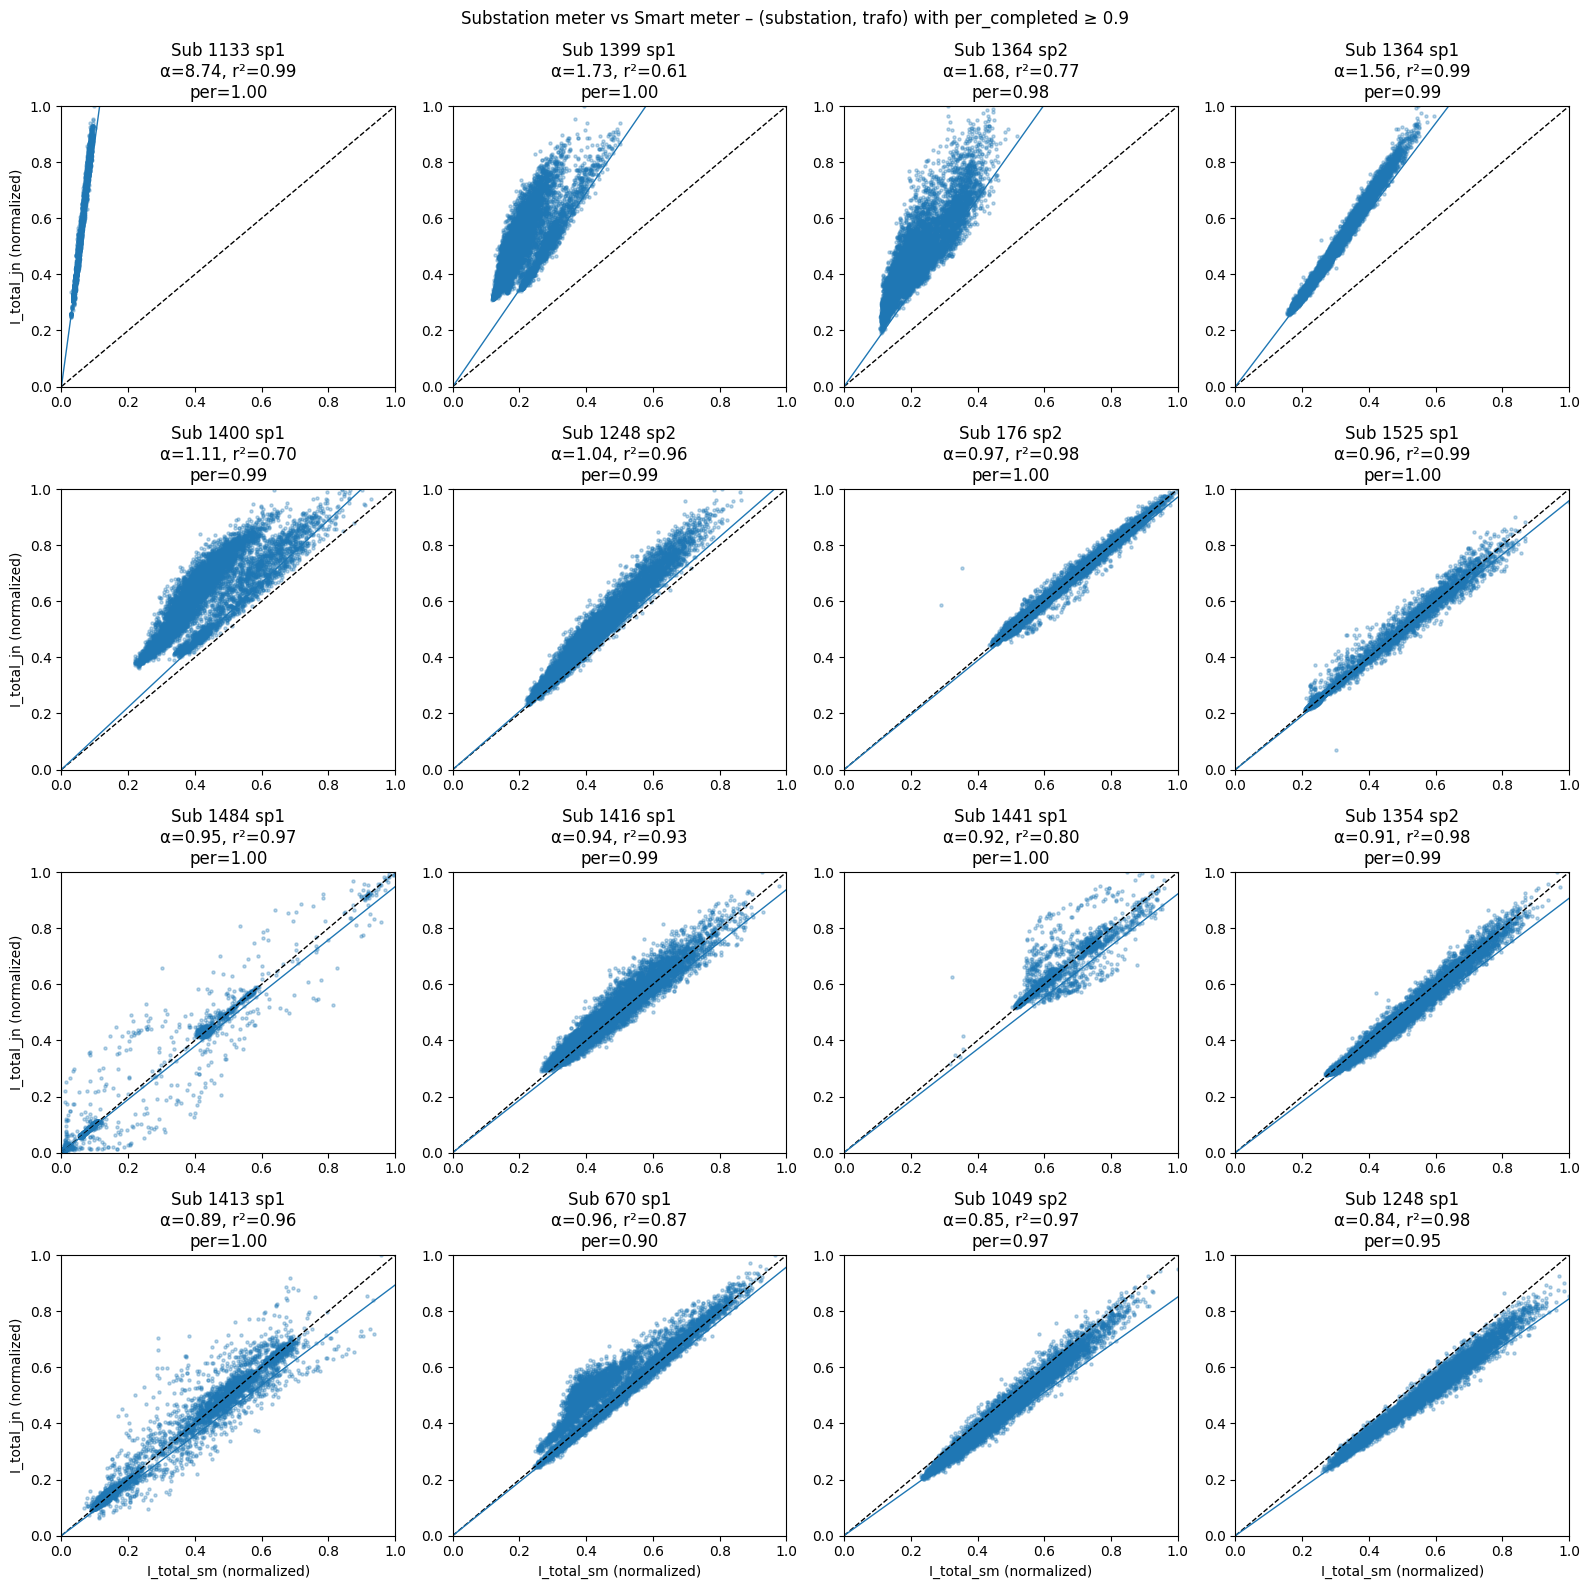

In [7]:
# This code block is for plotting a grid of time series for multiple substations and transformers.
#################################################################################################################
plot_scatter_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.9,
    max_plots=16,
    cols=4,
)
#################################################################################################################


Change in the ratio of SMD vs Janitza and after correction

Ratio can be misleading here are stations ploted with old smart meter current and corrected.

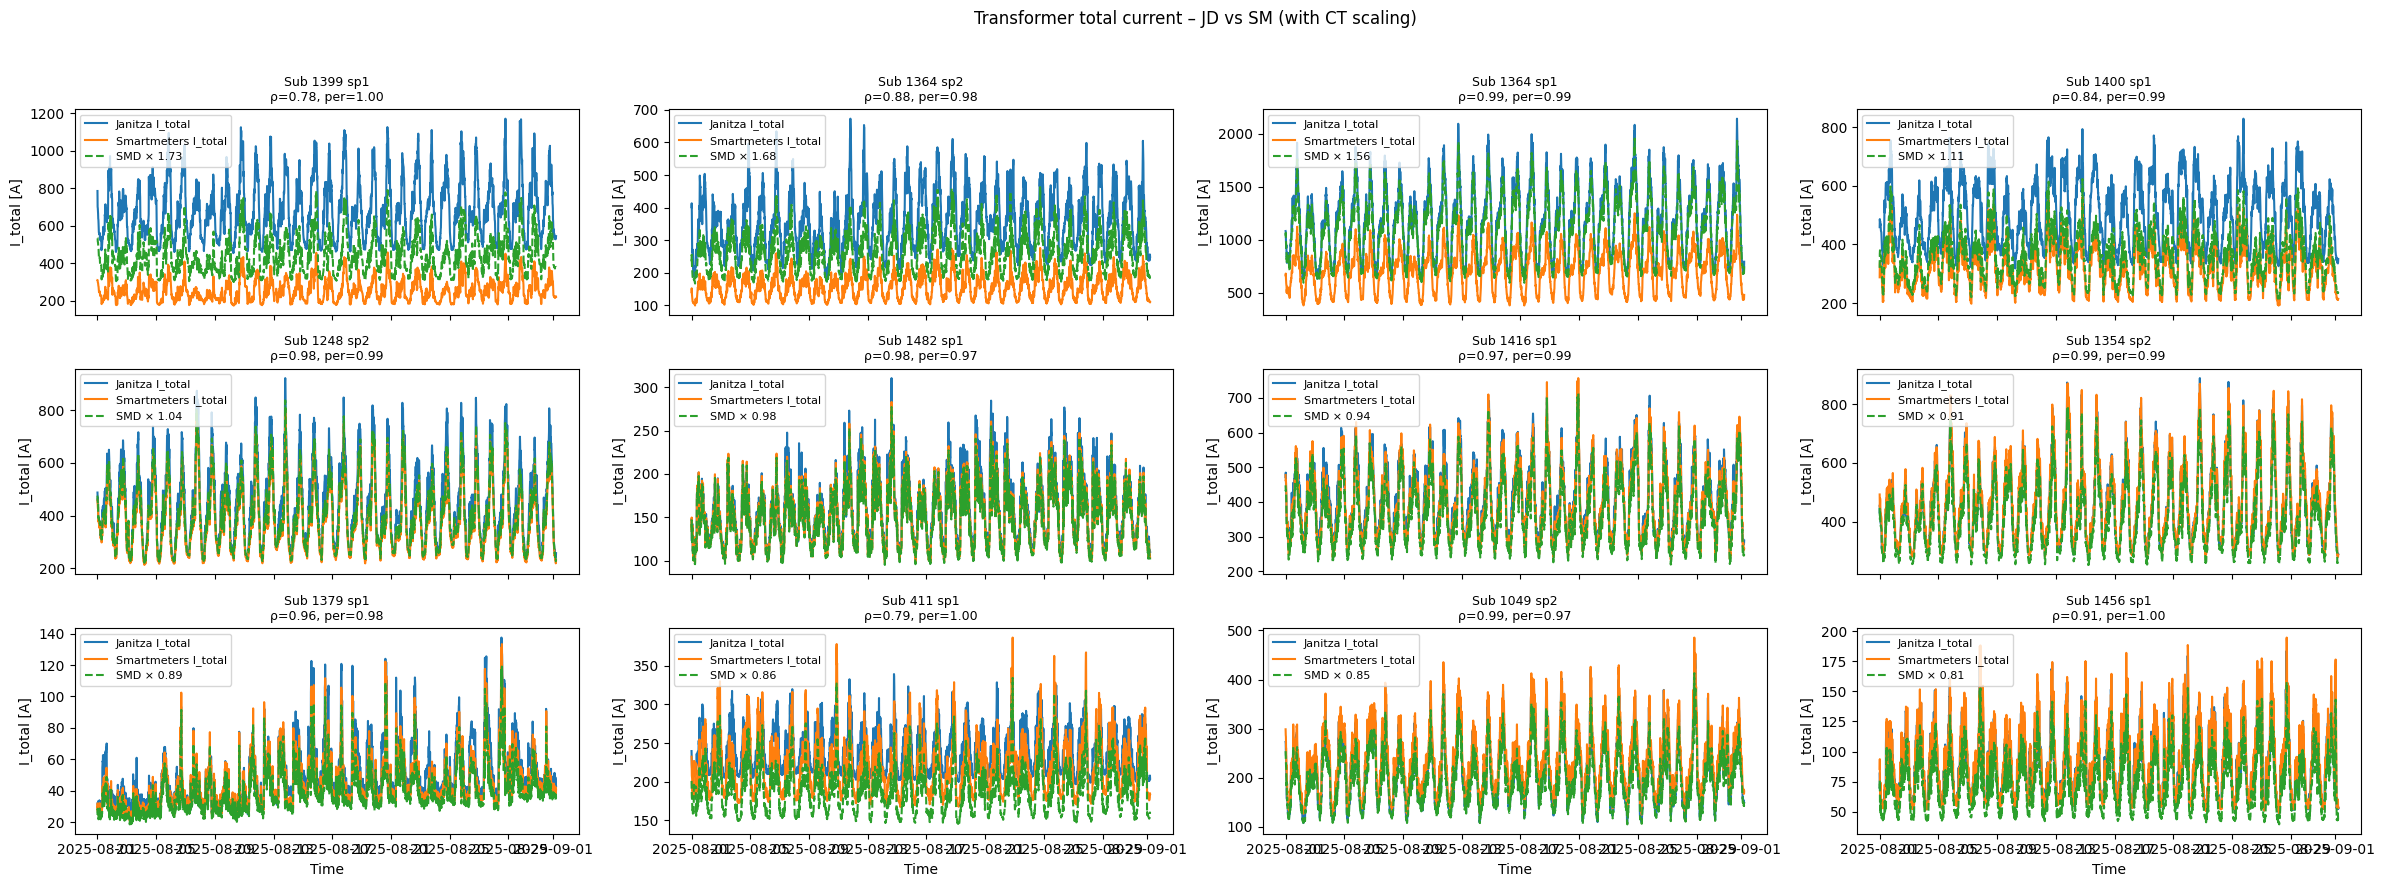

In [20]:
plot_substation_timeseries_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.96,
    max_plots=12,
    cols=4,
    max_points=3000,
)